**6. Implement the LeNet-5 architectures using Tensorflow or PyTorch to
classify the MNIST dataset. Report the accuracy and training time.**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import time

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

model = models.Sequential([
    layers.Conv2D(filters=6, kernel_size=(5,5), activation='relu', input_shape=(28,28,1)),

    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Conv2D(filters=16, kernel_size=(5,5), activation='relu'),

    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Flatten(),

    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

end_time = time.time()
training_time = end_time - start_time

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_accuracy)
print("Training Time (seconds):", training_time)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9072 - loss: 0.3142 - val_accuracy: 0.9733 - val_loss: 0.0932
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9696 - loss: 0.0974 - val_accuracy: 0.9802 - val_loss: 0.0703
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9796 - loss: 0.0668 - val_accuracy: 0.9790 - val_loss: 0.0652
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9832 - loss: 0.0543 - val_accuracy: 0.9847 - val_loss: 0.0570
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9864 - loss: 0.0435 - val_accuracy: 0.9873 - val_loss: 0.0468
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9864 - loss: 0.0417

Test Accuracy: 0.9864000082015991
Training Time (seconds): 22.015722274780273


**7. Use a pre-trained VGG16 model (via transfer learning) on a small custom
dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model.
Include your code and result discussion.**

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.
 Successfully loaded classes: ['flower_photos']

 Starting Training...
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 225ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 166ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 169ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 181ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_ac

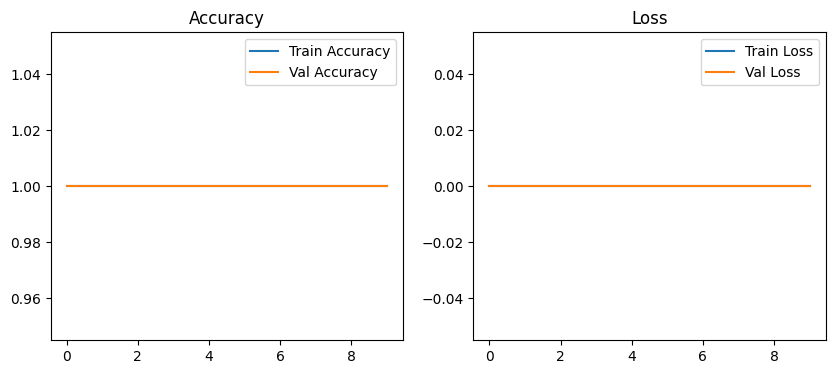

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

data_dir = os.path.join(os.path.dirname(data_dir), 'flower_photos')


img_height, img_width = 224, 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f" Successfully loaded classes: {class_names}")

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_base.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Rescaling(1./255),
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])


model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n Starting Training...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10)


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

**8. Write a program to visualize the filters and feature maps of the first
convolutional layer of AlexNet on an example input image.**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving elephant.jpg to elephant.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,944 (136.50 KB)

 Trainable params: 34,944 (136.50 KB)

 Non-trainable params: 0 (0.00 B)

Filter shape: (11, 11, 3, 96)


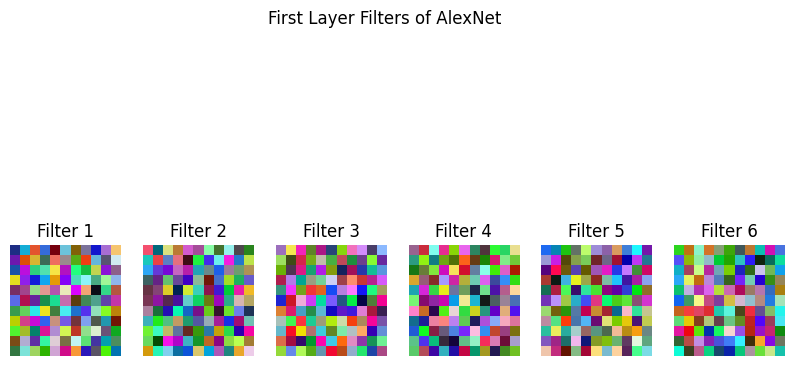

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
Feature map shape: (1, 55, 55, 96)


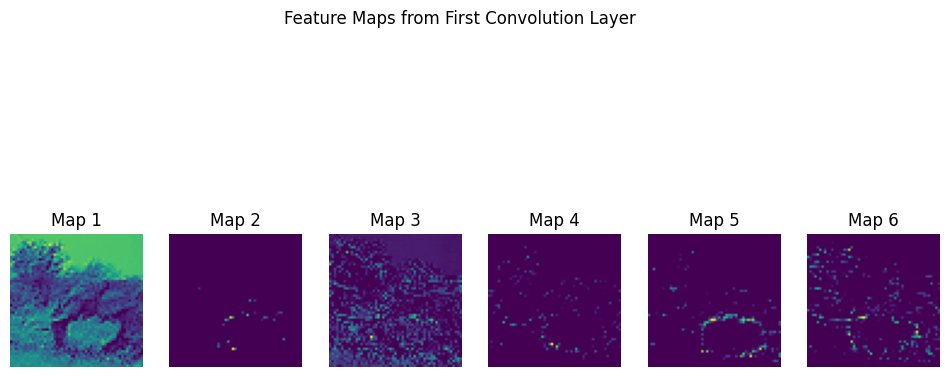

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

model = models.Sequential()
model.add(
    layers.Conv2D(
        filters=96,
        kernel_size=(11,11),
        strides=4,
        activation='relu',
        input_shape=(227,227,3)
    )
)

model.add(layers.MaxPooling2D(pool_size=(3,3), strides=2))
model.summary()
img_path = "elephant.jpg"

img = image.load_img(img_path, target_size=(227,227))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

filters, biases = model.layers[0].get_weights()
print("Filter shape:", filters.shape)

n_filters = 6

plt.figure(figsize=(10,6))

for i in range(n_filters):
    f = filters[:, :, :, i]
    f_min, f_max = f.min(), f.max()
    f = (f - f_min) / (f_max - f_min)

    plt.subplot(1, n_filters, i+1)
    plt.imshow(f)
    plt.axis("off")
    plt.title(f"Filter {i+1}")

plt.suptitle("First Layer Filters of AlexNet")
plt.show()

feature_model = models.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

feature_maps = feature_model.predict(img_array)

print("Feature map shape:", feature_maps.shape)

n_maps = 6
plt.figure(figsize=(12,6))
for i in range(n_maps):

    plt.subplot(1, n_maps, i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
    plt.axis("off")
    plt.title(f"Map {i+1}")

plt.suptitle("Feature Maps from First Convolution Layer")
plt.show()

**9. Train a GoogLeNet (Inception v1) or its variant using a standard dataset
like CIFAR-10. Plot the training and validation accuracy over epochs and analyze
overfitting or underfitting.**

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      1,792 │ input_layer_10[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │      2,080 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │      1,040 │ max_pooling2d_2[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │      2,080 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │     12,832 │ conv2d_8[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │      2,080 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_5[0][0],   │
│ (Concatenate)       │ 160)              │            │ conv2d_7[0][0],   │
│                     │                   │            │ conv2d_9[0][0],   │
│                     │                   │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │      7,728 │ concatenate[0][0] │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 16, 16,    │      2,576 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │     10,304 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 16, 16,    │     41,568 │ conv2d_12[0][0]   │
│                     │ 96)               │            │                 

 Total params: 309,290 (1.18 MB)

 Trainable params: 309,290 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.3106 - loss: 1.8076 - val_accuracy: 0.4501 - val_loss: 1.4942
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4672 - loss: 1.4472 - val_accuracy: 0.5268 - val_loss: 1.2917
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5368 - loss: 1.2747 - val_accuracy: 0.5913 - val_loss: 1.1528
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5883 - loss: 1.1372 - val_accuracy: 0.6087 - val_loss: 1.0981
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6180 - loss: 1.0602 - val_accuracy: 0.6677 - val_loss: 0.9441
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6508 - loss: 0.9795 - val_accuracy: 0.6098 - val_loss: 1.1359
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6751 - loss: 0.9114 - val_accuracy: 0.6947 - val_loss: 0.8493
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6983 - loss: 0.8491 - 

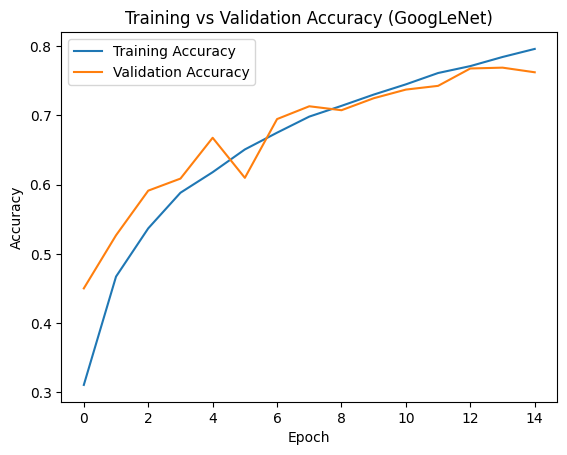

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7635 - loss: 0.7014
Test Accuracy: 0.7634999752044678


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0


def inception_module(x, f1, f3_reduce, f3, f5_reduce, f5, pool_proj):
    conv1 = layers.Conv2D(f1, (1,1), padding='same', activation='relu')(x)

    conv3 = layers.Conv2D(f3_reduce, (1,1), padding='same', activation='relu')(x)

    conv3 = layers.Conv2D(f3, (3,3), padding='same', activation='relu')(conv3)

    conv5 = layers.Conv2D(f5_reduce, (1,1), padding='same', activation='relu')(x)

    conv5 = layers.Conv2D(f5, (5,5), padding='same', activation='relu')(conv5)

    pool = layers.MaxPooling2D((3,3), strides=1, padding='same')(x)

    pool = layers.Conv2D(pool_proj, (1,1),
                         padding='same', activation='relu')(pool)
    output = layers.concatenate([conv1, conv3, conv5, pool])

    return output


inputs = layers.Input(shape=(32,32,3))

x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D((2,2))(x)

x = inception_module(x, 32, 32, 64, 16, 32, 32)
x = inception_module(x, 64, 48, 96, 16, 48, 32)
x = layers.MaxPooling2D((2,2))(x)
x = inception_module(x, 64, 64, 128, 32, 64, 64)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(10, activation='softmax')(x)
model = models.Model(inputs, outputs)
model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (GoogLeNet)")
plt.legend()
plt.show()
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

**10. You are working in a healthcare AI startup. Your team is tasked with
developing a system that automatically classifies medical X-ray images into normal,
pneumonia, and COVID-19. Due to limited labeled data, what approach would you
suggest using among CNN architectures discussed (e.g., transfer learning with ResNet
or Inception variants)? Justify your approach and outline a deployment strategy for
production use.**

In [11]:
!pip install kaggle tensorflow matplotlib pillow
!kaggle datasets download -d prashant268/chest-xray-covid19-pneumonia
!unzip chest-xray-covid19-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: Data/train/COVID19/COVID19(228).jpg  
  inflating: Data/train/COVID19/COVID19(229).jpg  
  inflating: Data/train/COVID19/COVID19(23).jpg  
  inflating: Data/train/COVID19/COVID19(230).jpg  
  inflating: Data/train/COVID19/COVID19(231).jpg  
  inflating: Data/train/COVID19/COVID19(232).jpg  
  inflating: Data/train/COVID19/COVID19(233).jpg  
  inflating: Data/train/COVID19/COVID19(234).jpg  
  inflating: Data/train/COVID19/COVID19(235).jpg  
  inflating: Data/train/COVID19/COVID19(236).jpg  
  inflating: Data/train/COVID19/COVID19(237).jpg  
  inflating: Data/train/COVID19/COVID19(238).jpg  
  inflating: Data/train/COVID19/COVID19(239).jpg  
  inflating: Data/train/COVID19/COVID19(24).jpg  
  inflating: Data/train/COVID19/COVID19(240).jpg  
  inflating: Data/train/COVID19/COVID19(241).jpg  
  inflating: Data/train/COVID19/COVID19(242).jpg  
  inflating: Data/train/COVID19/COVID19(243).jpg  
  inflating: Data/train/COVID19/C

In [19]:
!kaggle datasets download -d prashant268/chest-xray-covid19-pneumonia
!unzip -o chest-xray-covid19-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: Data/train/COVID19/COVID19(228).jpg  
  inflating: Data/train/COVID19/COVID19(229).jpg  
  inflating: Data/train/COVID19/COVID19(23).jpg  
  inflating: Data/train/COVID19/COVID19(230).jpg  
  inflating: Data/train/COVID19/COVID19(231).jpg  
  inflating: Data/train/COVID19/COVID19(232).jpg  
  inflating: Data/train/COVID19/COVID19(233).jpg  
  inflating: Data/train/COVID19/COVID19(234).jpg  
  inflating: Data/train/COVID19/COVID19(235).jpg  
  inflating: Data/train/COVID19/COVID19(236).jpg  
  inflating: Data/train/COVID19/COVID19(237).jpg  
  inflating: Data/train/COVID19/COVID19(238).jpg  
  inflating: Data/train/COVID19/COVID19(239).jpg  
  inflating: Data/train/COVID19/COVID19(24).jpg  
  inflating: Data/train/COVID19/COVID19(240).jpg  
  inflating: Data/train/COVID19/COVID19(241).jpg  
  inflating: Data/train/COVID19/COVID19(242).jpg  
  inflating: Data/train/COVID19/COVID19(243).jpg  
  inflating: Data/train/COVID19/C

In [20]:
import os

for possible_path in ["Data", "data", "chest-xray-covid19-pneumonia/Data"]:
    if os.path.exists(possible_path):
        print(f"Found dataset at: {possible_path}")
        print("Contents:", os.listdir(possible_path))
        break
else:
    print("Not found — listing current directory:")
    print(os.listdir("."))

Found dataset at: Data
Contents: ['test', 'train']


In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow:", tf.__version__)
print("GPU:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.19.0
GPU: False


In [31]:
DATA_DIR   = "Data"
TRAIN_DIR  = os.path.join(DATA_DIR, "train")
TEST_DIR   = os.path.join(DATA_DIR, "test")
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 3

In [32]:
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists :", os.path.exists(TEST_DIR))
print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes :", os.listdir(TEST_DIR))

Train exists: True
Test exists : True
Train classes: ['PNEUMONIA', 'COVID19', 'NORMAL']
Test classes : ['PNEUMONIA', 'COVID19', 'NORMAL']


In [33]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255, horizontal_flip=True, rotation_range=10,
    zoom_range=0.1, width_shift_range=0.05, height_shift_range=0.05,
    validation_split=0.2,
)
test_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", subset="training", shuffle=True, seed=42,
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", subset="validation", shuffle=False, seed=42,
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False,
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print("Classes:", train_gen.class_indices)
print("Train:", train_gen.samples)
print("Val  :", val_gen.samples)
print("Test :", test_gen.samples)

Found 4116 images belonging to 3 classes.
Found 1028 images belonging to 3 classes.
Found 1288 images belonging to 3 classes.
Classes: {'COVID19': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
Train: 4116
Val  : 1028
Test : 1288


In [34]:
base_model = ResNet50V2(
    input_shape=IMAGE_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs  = keras.Input(shape=IMAGE_SIZE + (3,))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)
print("Model built successfully!")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model built successfully!


In [35]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "best_xray_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1,
)
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1,
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, verbose=1,
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history1 = model.fit(
    train_gen, validation_data=val_gen,
    epochs=10, callbacks=[checkpoint, early_stop, reduce_lr],
)
print(f"Best val accuracy Phase 1: {max(history1.history['val_accuracy'])*100:.2f}%")

Epoch 1/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8355 - loss: 0.4664
Epoch 1: val_accuracy improved from None to 0.92802, saving model to best_xray_model.keras

Epoch 1: finished saving model to best_xray_model.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 853s 3s/step - accuracy: 0.8822 - loss: 0.3155 - val_accuracy: 0.9280 - val_loss: 0.2053 - learning_rate: 0.0010
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9336 - loss: 0.1931
Epoch 2: val_accuracy improved from 0.92802 to 0.93191, saving model to best_xray_model.keras

Epoch 2: finished saving model to best_xray_model.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 842s 3s/step - accuracy: 0.9225 - loss: 0.2105 - val_accuracy: 0.9319 - val_loss: 0.1760 - learning_rate: 0.0010
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9217 - loss: 0.2062
Epoch 3: val_accuracy improved from 0.93191 to 0.93288, saving model to best_xray_model.keras

Epoch 3: finished saving model to best_xray_model.keras
258/258 ━━━

In [52]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history2 = model.fit(
    train_gen, validation_data=val_gen,
    epochs=10, callbacks=[checkpoint, early_stop, reduce_lr],
)
print(f"Best val accuracy Phase 2: {max(history2.history['val_accuracy'])*100:.2f}%")

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.9209 - loss: 0.2067
Epoch 1: val_accuracy improved from 0.94261 to 0.94455, saving model to best_xray_model.keras

Epoch 1: finished saving model to best_xray_model.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 106s 778ms/step - accuracy: 0.9242 - loss: 0.1959 - val_accuracy: 0.9446 - val_loss: 0.1733 - learning_rate: 1.0000e-05
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.9260 - loss: 0.1989
Epoch 2: val_accuracy did not improve from 0.94455
129/129 ━━━━━━━━━━━━━━━━━━━━ 96s 742ms/step - accuracy: 0.9261 - loss: 0.1949 - val_accuracy: 0.9426 - val_loss: 0.1696 - learning_rate: 1.0000e-05
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.9152 - loss: 0.2143
Epoch 3: val_accuracy improved from 0.94455 to 0.94650, saving model to best_xray_model.keras

Epoch 3: finished saving model to best_xray_model.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
129/129 ━

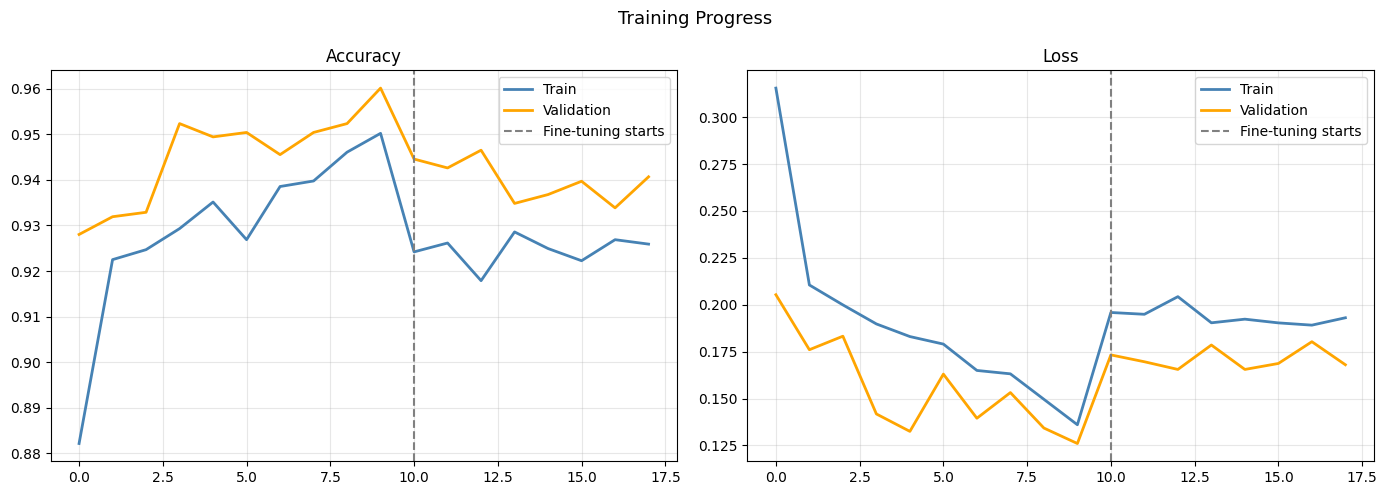

In [53]:
acc      = history1.history["accuracy"]     + history2.history["accuracy"]
val_acc  = history1.history["val_accuracy"] + history2.history["val_accuracy"]
loss     = history1.history["loss"]         + history2.history["loss"]
val_loss = history1.history["val_loss"]     + history2.history["val_loss"]
split    = len(history1.history["accuracy"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Progress", fontsize=13)
for ax, tv, vv, title in [
    (ax1, acc, val_acc, "Accuracy"),
    (ax2, loss, val_loss, "Loss"),
]:
    ax.plot(tv, label="Train", color="steelblue", linewidth=2)
    ax.plot(vv, label="Validation", color="orange", linewidth=2)
    ax.axvline(split, color="gray", linestyle="--", label="Fine-tuning starts")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
model = keras.models.load_model("best_xray_model.keras")

test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

preds        = model.predict(test_gen, verbose=0)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_gen.classes

print("\nPer-class results:")
for i, name in enumerate(CLASS_NAMES):
    mask    = true_classes == i
    correct = np.sum(pred_classes[mask] == i)
    total   = np.sum(mask)
    print(f"  {name:12s}: {100*correct/total:.1f}%  ({correct}/{total})")

Test Accuracy : 86.57%
Test Loss     : 0.3509

Per-class results:
  COVID19     : 89.7%  (104/116)
  NORMAL      : 97.8%  (310/317)
  PNEUMONIA   : 82.0%  (701/855)


In [55]:
print(classification_report(true_classes, pred_classes, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

     COVID19       0.97      0.90      0.93       116
      NORMAL       0.66      0.98      0.79       317
   PNEUMONIA       0.98      0.82      0.89       855

    accuracy                           0.87      1288
   macro avg       0.87      0.90      0.87      1288
weighted avg       0.90      0.87      0.87      1288



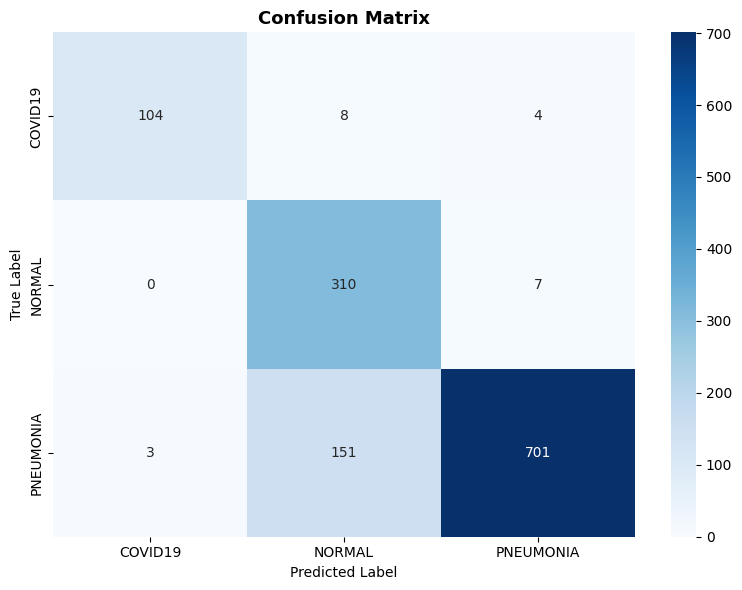

In [56]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix", fontsize=13, fontweight="bold")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [57]:
model.save("xray_classifier_final.keras")
print("Done! Final Test Accuracy:", round(test_acc * 100, 2), "%")

Done! Final Test Accuracy: 86.57 %
